# CT LAB: Simulating and Reconstructiong Tomography Data

Authors: L. Calatroni, A. Sebastiani (MaLGa, Unige)

Mini-course "Computational Imaging & Learning" - MSc in Data Science, University of Padua, Italy.

In the previous lab, we solved the inverse problem using **Model-Based Reconstruction**. 
We explicitly defined a regularization function and minimized a cost function. 
While mathematically rigorous, these hand-crafted priors often fail to capture the complex, high-frequency textures.

In this lab, we transition to **learned regularisation functionals**. Instead of manually defining the regularizaer, we will learn the prior distribution implicitly from data.

We will explore **Plug-and-Play (PnP) Priors**: We replace the proximal operator of the regularizer with a pre-trained deep denoising neural network (e.g., DRUNet). This is a hybrid approach that combines known physics with learned image statistics.

In [5]:
import deepinv as dinv
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
from pathlib import Path
from torchvision import transforms, datasets

from deepinv.optim.prior import Prior, PnP
from deepinv.optim.optimizers import optim_builder
from deepinv.training import test
from deepinv.models import DnCNN

# Set the global random seed from pytorch to ensure reproducibility of the example.
torch.manual_seed(42)

# Specify the device (to use GPU on colab, first change the runtime to T4 GPU)
device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"

# Use parallel dataloader if using a GPU to fasten training.
num_workers = 5 if torch.cuda.is_available() else 0

Selected GPU 0 with 4870.8125 MiB free memory


In [6]:
class GaussianNoiseCT(dinv.physics.GaussianNoise):
  def __init__(
        self,
        sigma: float | torch.Tensor = 0.1,
        rng: torch.Generator | None = None,
    ):
        super().__init__(sigma=sigma, rng=rng)

  def forward(self, x, sigma=None, seed=None, **kwargs):
        self.update_parameters(sigma=sigma, **kwargs)
        self.to(x.device)
        return (
            x
            + torch.max(torch.abs(x))*self.randn_like(x, seed=seed)
            * self.sigma[(...,) + (None,) * (x.dim() - 1)]
        )

# **Create the Physics: Radon Transform - Computed Tomography**

$$ \begin{aligned} \mathbf{y}(\boldsymbol{\theta},\rho) &= \int_{L_{\boldsymbol{\theta},\rho}}~u~d\sigma
\end{aligned} \qquad \boldsymbol{\theta} \in \R^2,~ \| \boldsymbol{\theta}\|=1, \quad \rho \in \mathbb{R}_+$$

($\mathbf{y}$ is usually referred to as the *sinogram* of $u$ and $L_{\boldsymbol{\theta},\rho} =  \left\{ \mathbf{x}: \mathbf{x}\cdot \boldsymbol{\theta} = \rho \right\}$)

In [7]:
noise_level_img = 0.1  # Gaussian Noise standard deviation for the degradation

angles = torch.tensor(np.linspace(0, 180, 30, endpoint=False)).to(device)

physics = dinv.physics.Tomography(
    img_width=28,
    angles=angles,
    circle=False,
    device=device,
    noise_model=GaussianNoiseCT(sigma=noise_level_img)
)

# **Create a dataset**

Next, we create a supervised dataset for the tomography problem by constructing
$$ \{(y_i,u_i)\}_{i=1}^N, \qquad u_i \text{: an image from dataset,}\quad y_i = \mathcal{R}u_i +\epsilon_i $$

Hint: use a rather small sample size $N$ to guarantee reasonable training times.

In [8]:
# Import the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])

Train_dataset = datasets.MNIST(root="../datasets/", train=True, transform=transform, download=True)
Test_dataset = datasets.MNIST(root="../datasets/", train=False, transform=transform, download=True)

# Create a supervised dataset of simulated measurements

# Specify the (maximum) size of the train and test sets
n_train_max = (250 if torch.cuda.is_available() else 50)  # number of images used for training
n_test_max = (50 if torch.cuda.is_available() else 10)  # number of images used for testing

# Set the path to save the datasets
BASE_DIR = Path(".")
measurement_dir = BASE_DIR / "dataset"

deepinv_datasets_path = dinv.datasets.generate_dataset(
    train_dataset=Train_dataset,
    test_dataset=Test_dataset,
    physics=physics,
    device=device,
    save_dir=measurement_dir,
    train_datapoints=n_train_max,
    test_datapoints=n_test_max,
    num_workers=num_workers,
    dataset_filename="tomo"
)

train_dataset = dinv.datasets.HDF5Dataset(path=deepinv_datasets_path, train=True)
test_dataset = dinv.datasets.HDF5Dataset(path=deepinv_datasets_path, train=False)

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.14MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 274kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 345kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.3MB/s]


Dataset has been saved at dataset/tomo0.h5


/home/mhetac/Documents/GitHub/CIL/CILvenv/lib64/python3.14/site-packages/deepinv/utils/plotting.py:439: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.2, wspace=0.2)


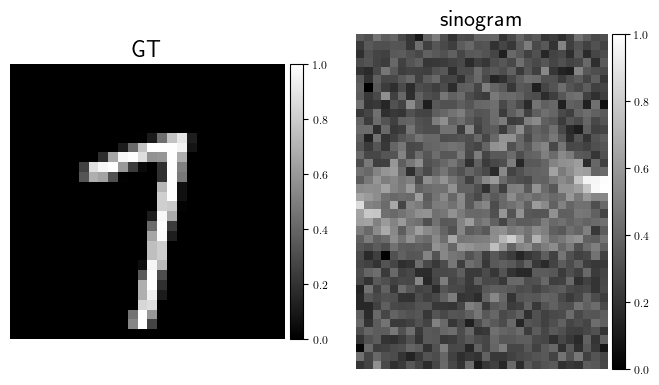

In [9]:
# Vizualize sample images from the dataset
select_image = 42
dinv.utils.plot([train_dataset[select_image][0], train_dataset[select_image][1]], ['GT', 'sinogram'], figsize=(8,4), cbar=True)

# **Variational regularisation techniques**

Choose a regularisation functional $\phi: \mathbb{R}^{n^2}\rightarrow \mathbb{R}$ and a parameter $\lambda >0 $ and solve
$$ u_\lambda \in \arg\min_{u \in \mathbb{R}^{n^2}} \left\{ \frac{1}{2}\| A u-y\|^2 + \lambda \phi(u)\right\}$$

Test:  98%|█████████▊| 49/50 [00:17<00:00,  2.89it/s, PSNR=15.1, PSNR no learning=12.5]

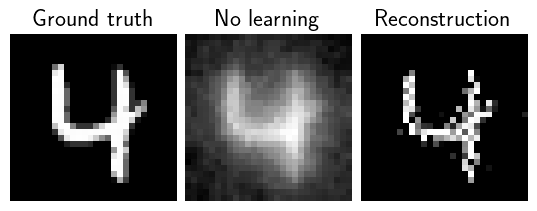

Test: 100%|██████████| 50/50 [00:18<00:00,  2.71it/s, PSNR=15.1, PSNR no learning=12.5]

Test results:
PSNR no learning: 12.451 +- 1.345
PSNR: 15.147 +- 1.784


{'PSNR no learning': 12.450964527130127,
 'PSNR no learning_std': 1.345188858250798,
 'PSNR': 15.146517601013183,
 'PSNR_std': 1.7840264434060498}

In [11]:
# Select the data fidelity term (the first part of the functional to be minimized)
data_fidelity = dinv.optim.data_fidelity.L2()

# Specify the custom prior R
prior = dinv.optim.L1Prior()

# Specific parameters for restoration with the given prior (Note that these parameters have not been optimized here)
params_algo = {"stepsize": 1., "lambda": 0.05}

# Instantiate the algorithm class to solve the IP problem
modelVAR = optim_builder(
    iteration="PGD", # proximal gradient descent
    prior=prior,
    g_first=False,
    data_fidelity=data_fidelity,
    params_algo=params_algo,
    early_stop=True,
    max_iter=500,
    crit_conv="cost",
    thres_conv=1e-5,
    backtracking=False,
    verbose=False,
)

# To get its 'average performances' we apply it to all the elements of the test set and take an average

batch_size = 1
var_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=0, shuffle=False)

test(
    model=modelVAR,
    test_dataloader=var_dataloader,
    physics=physics,
    device=device,
    verbose=True,
    plot_images = True,
)

**********************************************************
**TASK 2: Explore other regularization choices**

Explore alternative choices for $\phi$. Have a look at https://deepinv.github.io/deepinv/api/stubs/deepinv.optim.Prior.html#deepinv.optim.Prior


**********************************************************

Test:  98%|█████████▊| 49/50 [11:31<00:11, 11.43s/it, PSNR=15, PSNR no learning=12.5]  

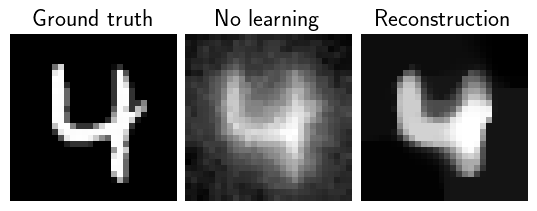

Test: 100%|██████████| 50/50 [11:31<00:00, 13.82s/it, PSNR=15, PSNR no learning=12.5]

Test results:
PSNR no learning: 12.451 +- 1.345
PSNR: 15.003 +- 1.505


{'PSNR no learning': 12.450964527130127,
 'PSNR no learning_std': 1.345188858250798,
 'PSNR': 15.00293788909912,
 'PSNR_std': 1.5045370498622657}

In [13]:
# Select the data fidelity term (the first part of the functional to be minimized)
data_fidelity = dinv.optim.data_fidelity.L2()

# Check the TV prior (check https://deepinv.github.io/deepinv/auto_examples/optimization/demo_TV_minimisation.html )
prior = dinv.optim.TVPrior()

# Specific parameters for restoration with the given prior (Note that these parameters have not been optimized here)
params_algo = {"stepsize": 1., "lambda": 0.05}

# Instantiate the algorithm class to solve the IP problem
modelVAR = optim_builder(
    iteration="PGD", # proximal gradient descent
    prior=prior,
    g_first=False,
    data_fidelity=data_fidelity,
    params_algo=params_algo,
    early_stop=True,
    max_iter=500,
    crit_conv="cost",
    thres_conv=1e-5,
    backtracking=False,
    verbose=False,
)

# To get its 'average performances' we apply it to all the elements of the test set and take an average

batch_size = 1
var_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=0, shuffle=False)

test(
    model=modelVAR,
    test_dataloader=var_dataloader,
    physics=physics,
    device=device,
    verbose=True,
    plot_images = True,
)

**********************************************************
**TASK (Optional): Parameter Tuning**

Find the best choice for the parameter $\lambda$ by means of a supervised strategy.

Define a pool of possible parameters $\{10^{-7},10^{-6.5},\ldots,10^{-1},10^{-0.5},1\}$ and, for each of them, evaluate the performance on the training set. Then, pick the best one and use it on the test set.



**********************************************************

## **Plug-and-Play 1: PGD with pre-trained denoiser**

Consider the Proximal Gradient Descent (PGD) method associated with the minimization of the functional $\frac{1}{2}\| Au-y \|^2 + \lambda \phi(f)$, namely
$$
\left\{
\begin{aligned}
z^{(k+1)} &= u^{(k)} - \tau A^\top(Au^{(k)}-y) \\
u^{(k+1)} &= \operatorname{prox}_{\tau \lambda \phi}(z^{(k+1)})
\end{aligned}
\right.
$$
and replace the proximal operator of $\tau \lambda \phi$ by a neural network $D_{\theta,\sigma}$, obtaining
$$
\left\{
\begin{aligned}
z^{(k+1)} &= u^{(k)} - \tau A^\top(Au^{(k)}-y) \\
u^{(k+1)} &= D_{\theta,\sigma}(z^{(k+1)})
\end{aligned}
\right.
$$
The network $D_{\theta,\sigma}$ (depending on some parameters $\theta$) plays the role of a denoiser, and in particular it is trained to remove Gaussian noise, i.e., to approximate the MMSE denoiser associated with the prior distribution corrupted by Gaussian noise with standard deviation $\sigma$.

Let us first consider a simple case in which $D_{\theta,\sigma}$ is a CNN that has been pre-trained on natural images.

Test:  98%|█████████▊| 49/50 [00:15<00:00,  3.12it/s, PSNR=13, PSNR no learning=12.5]  

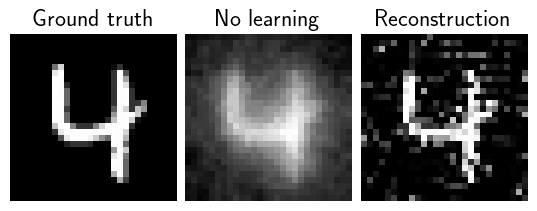

Test: 100%|██████████| 50/50 [00:15<00:00,  3.18it/s, PSNR=13, PSNR no learning=12.5]

Test results:
PSNR no learning: 12.451 +- 1.345
PSNR: 13.026 +- 1.418


{'PSNR no learning': 12.450964527130127,
 'PSNR no learning_std': 1.345188971683109,
 'PSNR': 13.026129951477051,
 'PSNR_std': 1.4180158216794583}

In [15]:
from deepinv.models import DnCNN

sigma_PnP = 0.1  # matched to noise_level_img; tune between 0.01 and 0.2
params_algo = {"stepsize": 0.8, "g_param": sigma_PnP}
max_iter = 200
early_stop = True

denoiser = DnCNN(
    in_channels=1, # for greyscale images
    out_channels=1,
    pretrained="download",  # try also "download_lipschitz", it has convergence guarantees, but less expressivity
    device=device,
)
prior = PnP(denoiser=denoiser)

data_fidelity = dinv.optim.data_fidelity.L2()


# Instantiate the algorithm class to solve the IP problem
modelPnP = optim_builder(
    iteration="PGD",
    prior=prior,
    data_fidelity=data_fidelity,
    early_stop=early_stop,
    max_iter=max_iter,
    verbose=True,
    params_algo=params_algo,
)
modelPnP.eval() # set the model to evaluation mode. We do not require training here


# Set the data loader to test the regularizer
batch_size = 1
var_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=0, shuffle=False)

test(
    model=modelPnP,
    test_dataloader=var_dataloader,
    physics=physics,
    device=device,
    verbose=True,
    plot_images = True,
)


# What is the effect of a different choice of sigma?

# **Plug-and-Play 2: let's also train the denoiser - your turn!**

We want to use in PGD a network specifically trained to denoise images from the our dataset.
To do so,
1.   we create another dataset $\{\tilde{u}_i,u_i\}_{i=1}^{N_{den}}$ such that $\tilde{u}_i = u_i + \tilde{\epsilon}_i$, where $\tilde{\epsilon}_i \sim \mathcal{N}(0,\sigma^2 I)$
2.   we define a denoiser $D_\theta$ as a CNN as above and train it, namely we choose its parameters $\theta$ so to minimize $$L_{den}(\theta) = \frac{1}{N_{den}} \sum_{i=1}^{N_{den}} \| D_\theta(\tilde{u}_i) - u_i\|^2$$
3.  we use the trained denoiser $ D_{\theta,\sigma}$ in place of the prox of a regularization functional in any PnP scheme - e.g. PnP-PGD

Follow the steps below to implement this strategy.

In [16]:
# Part 1: dataset

denoiser_train = DnCNN(   # Try also UNet
    in_channels=1,
    out_channels=1,
    pretrained="download",
    device=device,
)

# Create a supervised dataset of simulated measurements

# Specify the (maximum) size of the train and test sets
n_train_max_PnP = (250 if torch.cuda.is_available() else 50)  # number of images used for training
n_test_max_PnP = (50 if torch.cuda.is_available() else 10)  # number of images used for testing

# Set the path to save the datasets
BASE_DIR = Path(".")
measurement_dir = BASE_DIR / "dataset"

# Define the physics: COMPLETE!
# Check https://deepinv.github.io/deepinv/api/stubs/deepinv.physics.Denoising.html

sigma_PnP = 0.05
noise_model_PnP = dinv.physics.GaussianNoise(sigma=sigma_PnP)
physics_PnP = dinv.physics.Denoising(noise_model=noise_model_PnP)

# Generate noisy dataset
deepinv_datasets_path_PnP = dinv.datasets.generate_dataset(
    train_dataset=Train_dataset,
    test_dataset=Test_dataset,
    physics=physics_PnP,
    device=device,
    save_dir=measurement_dir,
    train_datapoints=n_train_max_PnP,
    test_datapoints=n_test_max_PnP,
    num_workers=num_workers,
    dataset_filename="denoise",
)

train_dataset_PnP = dinv.datasets.HDF5Dataset(path=deepinv_datasets_path_PnP, train=True)
test_dataset_PnP = dinv.datasets.HDF5Dataset(path=deepinv_datasets_path_PnP, train=False)

Dataset has been saved at dataset/denoise0.h5


The model has 665921 trainable parameters
Train epoch 0: TotalLoss=0.003, PSNR=25.429
Eval epoch 0: PSNR=26.019
Best model saved at epoch 1
Train epoch 1: TotalLoss=0.003, PSNR=26.013
Eval epoch 1: PSNR=26.034
Best model saved at epoch 2
Train epoch 2: TotalLoss=0.002, PSNR=26.128
Eval epoch 2: PSNR=26.543
Best model saved at epoch 3
Train epoch 3: TotalLoss=0.002, PSNR=27.225
Eval epoch 3: PSNR=28.534
Best model saved at epoch 4
Train epoch 4: TotalLoss=0.001, PSNR=29.381
Eval epoch 4: PSNR=30.456
Best model saved at epoch 5
Train epoch 5: TotalLoss=0.001, PSNR=31.122
Eval epoch 5: PSNR=32.092
Best model saved at epoch 6
Train epoch 6: TotalLoss=0.001, PSNR=32.202
Eval epoch 6: PSNR=33.043
Best model saved at epoch 7
Train epoch 7: TotalLoss=0.001, PSNR=33.105
Eval epoch 7: PSNR=33.708
Best model saved at epoch 8
Train epoch 8: TotalLoss=0.0, PSNR=33.345
Eval epoch 8: PSNR=34.013
Best model saved at epoch 9
Train epoch 9: TotalLoss=0.0, PSNR=33.843
Eval epoch 9: PSNR=34.318
Best model

Test:   0%|          | 0/5 [00:00<?, ?it/s, PSNR=35.1, PSNR no learning=26]  

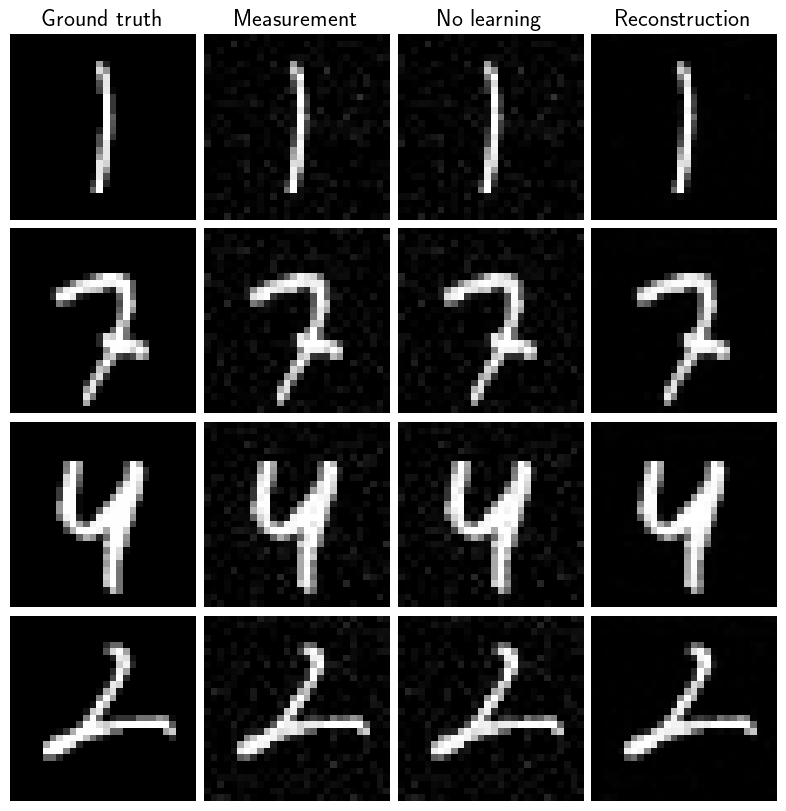

Test: 100%|██████████| 5/5 [00:00<00:00,  9.30it/s, PSNR=35.1, PSNR no learning=26]

Test results:
PSNR no learning: 26.028 +- 0.234
PSNR: 35.069 +- 1.403


DnCNN(
  (in_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_list): ModuleList(
    (0-17): 18 x Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (out_conv): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (nl_list): ModuleList(
    (0-18): 19 x ReLU()
  )
)

In [18]:
# Part 2: training

data_fidelity = dinv.optim.data_fidelity.L2()

# Set the dataloader for the training
batch_size=10
train_dataloader_PnP = DataLoader(train_dataset_PnP, batch_size=batch_size, num_workers=0, shuffle=False)
test_dataloader_PnP = DataLoader(test_dataset_PnP, batch_size=batch_size, num_workers=0, shuffle=False)

# Set the training algorithm
learning_rate = 1e-3
epochs = 20
optimizer = torch.optim.Adam(denoiser_train.parameters(), lr=learning_rate)
losses = [dinv.loss.SupLoss(metric=dinv.loss.metric.MSE())]

trainer_den = dinv.Trainer(
    model=denoiser_train,
    physics=physics_PnP,
    train_dataloader=train_dataloader_PnP,
    eval_dataloader=test_dataloader_PnP,
    epochs=epochs,
    losses=losses,
    optimizer=optimizer,
    device=device,
    verbose=True,
    show_progress_bar=False,
)

# Training
modelDenoiser = trainer_den.train()
test(
    model=denoiser_train,
    test_dataloader=test_dataloader_PnP,
    physics=physics_PnP,
    device=device,
    verbose=True,
    plot_images = True,
)

# Training is over: now let us use the trained model
modelDenoiser.eval()

**********************************************************
**TASK: Use your brand new denoiser! **

Use the trained denoiser within a simple PnP-PGD scheme.

Hint: since the prior is strong, you can use a small regularization parameter. This is encoded by selecting a large stepsize.


**********************************************************

/home/mhetac/Documents/GitHub/CIL/CILvenv/lib64/python3.14/site-packages/deepinv/training/trainer.py:549: UserWarning: Update progress bar frequency of 1 may slow down training on GPU. Consider setting freq_update_progress_bar > 1.
  warnings.warn(
Test:  98%|█████████▊| 49/50 [00:14<00:00,  3.23it/s, PSNR=20.6, PSNR no learning=12.5]

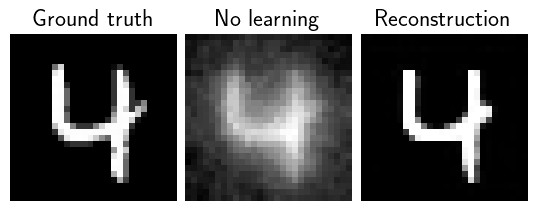

Test: 100%|██████████| 50/50 [00:14<00:00,  3.37it/s, PSNR=20.6, PSNR no learning=12.5]

Test results:
PSNR no learning: 12.451 +- 1.345
PSNR: 20.582 +- 1.874


{'PSNR no learning': 12.450964603424072,
 'PSNR no learning_std': 1.3451888893899835,
 'PSNR': 20.5815026473999,
 'PSNR_std': 1.873924364821284}

In [19]:
# Solution: Part 3

params_algo = {"stepsize": 1.0, "g_param": sigma_PnP}
max_iter = 200
early_stop = True

prior = PnP(denoiser=modelDenoiser)

data_fidelity = dinv.optim.data_fidelity.L2()

# Instantiate the algorithm class to solve the IP problem: COMPLETE
modelPnP_new = optim_builder(
    iteration="PGD",
    prior=prior,
    data_fidelity=data_fidelity,
    early_stop=early_stop,
    max_iter=max_iter,
    verbose=True,
    params_algo=params_algo,
)
modelPnP_new.eval() # set the model to evaluation mode. We do not require training here

# Set the data loader to test the regularizer: COMPLETE
batch_size = 1
var_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=0, shuffle=False)

test(
    model=modelPnP_new,
    test_dataloader=var_dataloader,
    physics=physics,
    device=device,
    verbose=True,
    plot_images=True,
)